# Importing Required Libraries

In [1]:
# pytorch 
import torch
import torchaudio

import numpy as np
import pandas as pd

import os
import shutil
from pathlib import Path
from glob import glob
from tqdm.notebook import tqdm
import random

import warnings
warnings.filterwarnings('ignore')

import seaborn as sns
import matplotlib.pyplot as plt
import math

# Defining paths

In [2]:
STEMS_DIR = "/kaggle/input/jan-2026-dl-gen-ai-project/messy_mashup/genres_stems"
NOISE_DIR = "/kaggle/input/jan-2026-dl-gen-ai-project/messy_mashup/ESC-50-master/audio/"
BPM_CSV = "/kaggle/input/bpm-calculator-ipynb/bpm.csv"

OUTPUT_DIR = "/kaggle/working/train_data"  # This will be saved as dataset
MAX_STORAGE_GB = 10  # creating mel spectogram untill we reach 8gb

SR = 16000   #sample_rate
DURATION = 10.24  # audio duration in seconds

GENRES = ["blues", "classical", "country", "disco", "hiphop",
          "jazz", "metal", "pop", "reggae", "rock"]

# Creating data generator

In [3]:
def get_dir_size_gb(path):
    """Get directory size in GB."""
    if not os.path.exists(path):
        return 0
    total = sum(f.stat().st_size for f in Path(path).rglob('*') if f.is_file())
    return total / (1024**3)

class MelGenerator:
    
    def __init__(self, stems_dir, noise_dir, bpm_cache):
        self.stems_dir = stems_dir
        self.noise_dir = noise_dir
        self.sr = SR  
        self.num_samples = 163840
        self.bpm_cache = bpm_cache
        
        self.mel = torchaudio.transforms.MelSpectrogram(
            sample_rate=self.sr, # number of samples per second 16000 in this case
            n_fft=400,        # 400 frequency bins the fourier tranform calculates
            win_length=400,   # 400 samples are analyzed at one moment for creating spectrogram
            hop_length=160 ,  # 160 samples the window slides after each calculation
            n_mels=128,        # 128 frequency bands
            f_min=0,          # minimun frequency 
            f_max=8000,       # maximum frequency
            normalized=True,   # normalization
        )
        self.db = torchaudio.transforms.AmplitudeToDB()

        self.label_map = {g: i for i, g in enumerate(GENRES)}

        # Load all stem paths
        self.stems = {g: {'drums':[],'bass':[],'other':[],'vocals':[]} for g in GENRES}
        
        print("Loading stem paths")
        for genre in GENRES:
            gp = f'{stems_dir}/{genre}'
            self.stems[genre]['bass'] = sorted(glob(f"{gp}/*/bass.wav"))
            self.stems[genre]['drums'] = sorted(glob(f"{gp}/*/drums.wav"))
            self.stems[genre]['other'] = sorted(glob(f"{gp}/*/other.wav"))
            self.stems[genre]['vocals'] = sorted(glob(f"{gp}/*/vocals.wav"))

        self.noise_files = sorted(glob(f'{noise_dir}*.wav'))
        
    def load_audio(self, path, target_samples):
        """Load and preprocess audio."""   
            
        audio , sr = torchaudio.load(path)
        
        if sr != self.sr:   # consistent sample rate
            audio = torchaudio.functional.resample(audio, sr, self.sr)

        if audio.shape[0] != 1:  # converting dual to mono audio
            audio = audio.mean(axis=0,keepdim=True)

        if audio.shape[1] < target_samples: # padding for short audios
            audio = torch.nn.functional.pad(audio, (0, target_samples - audio.shape[1]))

        if audio.shape[1] > target_samples: 
            audio = audio[:, :target_samples]
     
        return audio
    
    def create_mashup(self, genre):
        
        stems = [
            random.choice(self.stems[genre]['bass']),
            random.choice(self.stems[genre]['drums']),
            random.choice(self.stems[genre]['other']),
            random.choice(self.stems[genre]['vocals']),
        ]
        
        if random.random() > 0.5:
            #  50% probability of creating a mashup with size not equal to 30 sec
            if random.random() < 0.2:   
                # 20% probability of creating a mashup with size between 6 to 27 sec
                target_samples = int(random.randint(6,27) * self.sr)
            else:
                # 80% probability of creating a mashup with size between 27 to 30 sec
                target_samples = int(random.randint(27,30) * self.sr)
        else:
            # no change in size
            target_samples = 30*self.sr


        mixed = torch.zeros((1, target_samples))
        target_bpm = self.bpm_cache.get(random.choice(stems))

        balance_change = random.random() # to decide if we want to change balance of stems or not 

        for path in stems:
            bpm = self.bpm_cache.get(path)
            audio  = self.load_audio(path, target_samples)
            rate = bpm/target_bpm
                
            if abs(rate-1.0) > 0.01:
                new_length = int(audio.shape[-1] / rate)
                if new_length < 1:
                    new_length = audio.shape[-1]

                audio = audio.unsqueeze(0)
                audio = torch.nn.functional.interpolate(
                    audio, size=new_length, mode='linear', align_corners=False
                )
                    
                if audio.shape[-1] < target_samples:
                    audio = torch.nn.functional.pad(
                        audio, (0, target_samples - audio.shape[-1])
                    )
                        
                if audio.shape[-1] > target_samples:
                    # Center crop after tempo stretch
                    start = (audio.shape[-1] - target_samples) // 2
                    audio = audio[:, :, start:start + target_samples]
                        
            audio = audio.squeeze(0)
            
            if balance_change < 0.4:
                # 40% probability of changing balance
                mixed += (audio * random.uniform(0.4,1))
            else:
               mixed += audio    
            
            # injecting noise

        if random.random() > 0.3:
            noise, noise_sr = torchaudio.load(random.choice(self.noise_files))
            
            if noise_sr != self.sr:
                noise = torchaudio.functional.resample(noise, noise_sr, self.sr)
            if noise.shape[0] > 1:
                noise = noise.mean(dim=0, keepdim=True)
                
                
            intensity = random.uniform(0.1, 0.8)
            noise_len = noise.shape[1]
    
            diff = target_samples - noise_len
            
            if diff > 0:
                start = torch.randint(0, diff, (1,)).item()
                mixed[:, start:start+noise_len] += noise * intensity
            elif diff < 0:
                # Noise is longer than target
                start = torch.randint(0, abs(diff), (1,)).item()
                mixed += noise[:, start:start+target_samples] * intensity
            else:
                # They are exactly the same size
                mixed += noise * intensity

        # mixed = torch.tanh(mixed)

        mel_segments = []

        # break audio into 10.24 sec parts
        for i in range(0,target_samples,self.num_samples):  
            # chopping
            chunk = mixed[:, i : i + self.num_samples]
            # padding
            if chunk.shape[1] < self.num_samples:
                    chunk = torch.nn.functional.pad(chunk, (0, self.num_samples - chunk.shape[1]))
                
            # Mel spectrogram
            mel_spec = self.mel(chunk)
            # mel_db = self.db(mel_spec)
            mel_db = torch.log(mel_spec + 1e-6)
            # mel_db = torch.clamp(mel_db, min=-100)

            mel_segments.append(mel_db.squeeze(0))

        return mel_segments

In [4]:
def generate():

    bpm_df = pd.read_csv(BPM_CSV)
    bpm_cache = dict(zip(bpm_df["path"], bpm_df["bpm"]))
    del bpm_df

    # Create generator
    gen = MelGenerator(STEMS_DIR, NOISE_DIR, bpm_cache)

    # Create directories
    base = Path(OUTPUT_DIR)
    base.mkdir(exist_ok=True)
    
    # Ensure genre subdirectories exist
    genre_dirs = {}
    for g in GENRES:
        d = base / g
        d.mkdir(exist_ok=True)
        genre_dirs[g] = d

    # Track counts
    counts = {g: 0 for g in GENRES}
    total = 0
    genre_idx = 0

    print(f"\nTarget: {MAX_STORAGE_GB} GB")
    print("Starting data generation\n")

    pbar = tqdm(desc="Generating", unit=" samples")
    
    storage_check_counter = 0

    try:
        while True:
            
            if storage_check_counter >= 50:
                used = get_dir_size_gb(OUTPUT_DIR)
                if used >= MAX_STORAGE_GB:
                    print(f"\nReached {MAX_STORAGE_GB}GB limit")
                    break
                
                pbar.set_postfix({
                    'GB': f'{used:.2f}/{MAX_STORAGE_GB}',
                    'Min': f'{min(counts.values())}' 
                })
                storage_check_counter = 0

            genre = GENRES[genre_idx % len(GENRES)]

            try:

                mel_list = gen.create_mashup(genre)


                for mel_tensor in mel_list:
                    
                    mel_numpy = mel_tensor.cpu().detach().numpy()

                    fname = f"{genre}_version_3_{counts[genre]:06d}.npz"
                    save_path = genre_dirs[genre] / fname

                    np.savez_compressed(
                        save_path,
                        mel_spectrogram=mel_numpy
                    )

                    counts[genre] += 1
                    total += 1
                    storage_check_counter += 1
                    pbar.update(1)

                genre_idx += 1

            except Exception as e:
                print(f"\nError processing {genre}: {e}")
                genre_idx += 1
                continue

    except KeyboardInterrupt:
        print("\n\nStopped by user")

    pbar.close()
    return counts

In [5]:
counts = generate()
print("Data generation complete")

Loading stem paths

Target: 10 GB
Starting data generation



Generating: 0 samples [00:00, ? samples/s]



Stopped by user
Data generation complete


# Generated Training data

  0%|          | 0/2 [00:00<?, ?it/s]

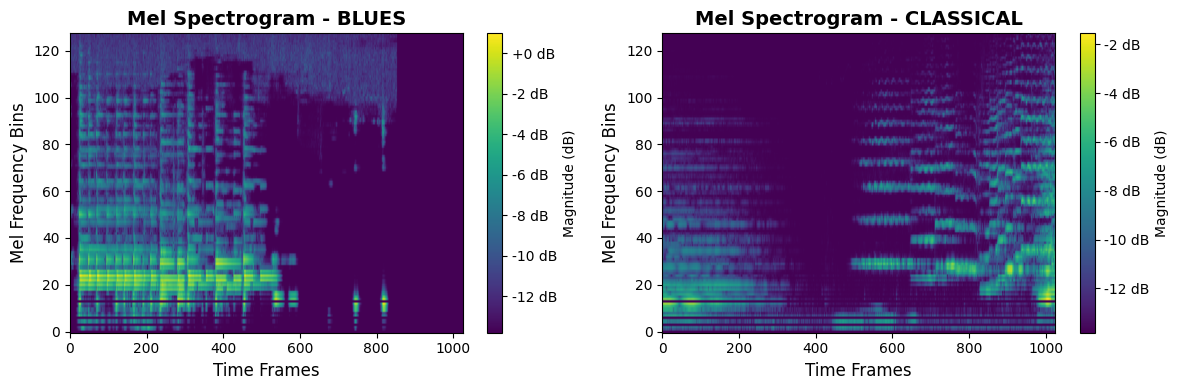

In [11]:
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(12,4))
axes = axes.flatten()
for i in tqdm(range(2)):
    genre = GENRES[i%10]
    mel_spectogram_path = glob(f"{OUTPUT_DIR}/{genre}/*.npz")
    chosen_spectogram = random.choice(mel_spectogram_path)
    data = np.load(chosen_spectogram)
    mel = data['mel_spectrogram']
    
    ax = axes[i]
    img = ax.imshow(mel.squeeze(), aspect='auto', origin='lower', cmap='viridis')
    ax.set_title(f'Mel Spectrogram - {genre.upper()}', fontsize=14, fontweight='bold')
    ax.set_xlabel('Time Frames', fontsize=12)
    ax.set_ylabel('Mel Frequency Bins', fontsize=12)

    fig.colorbar(img, ax=ax, format='%+2.0f dB', label='Magnitude (dB)')
    
plt.tight_layout()
plt.show()

# Test data

  0%|          | 0/2 [00:00<?, ?it/s]

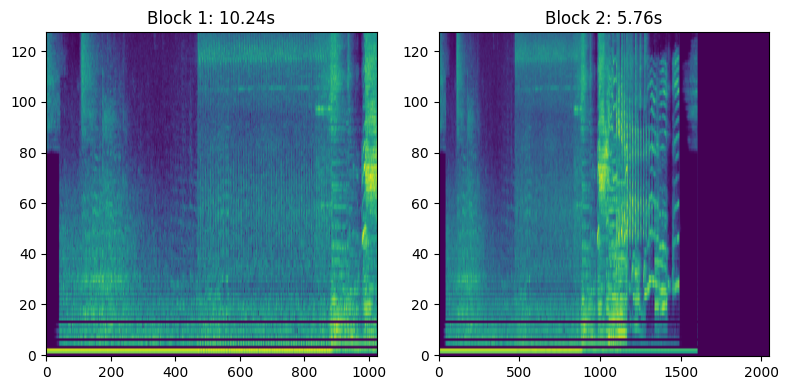

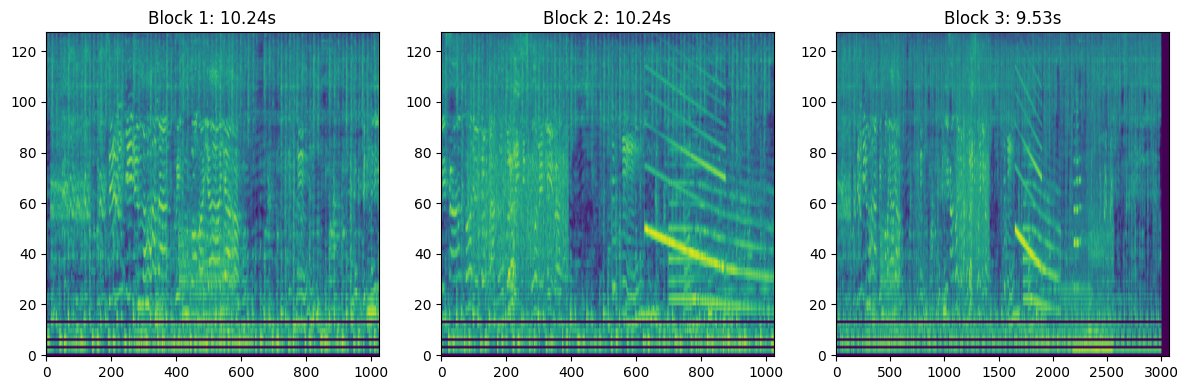

In [7]:
path = glob(f'/kaggle/input/jan-2026-dl-gen-ai-project/messy_mashup/mashups/*.wav')

samples = int(DURATION * SR)

mel_transform = torchaudio.transforms.MelSpectrogram(
            sample_rate=SR, # number of samples per second 16000 in this case
            n_fft=400,        # 400 frequency bins the fourier tranform calculates
            win_length=400,   # 400 samples are analyzed at one moment for creating spectrogram
            hop_length=160 ,  # 160 samples the window slides after each calculation
            n_mels=128,        # 128 frequency bands
            f_min=0,          # minimun frequency 
            f_max=8000,       # maximum frequency
            normalized=True,   # normalization for consistent peaks 
)

for i in tqdm(range(2)):
    test_samples = random.choice(path)
    audio , sr_loaded = torchaudio.load(test_samples)

    if sr_loaded != SR:
        audio = torchaudio.functional.resample(audio, sr_loaded, SR)

    if audio.shape[0] > 1:
        audio = audio.mean(dim=0, keepdim=True)

    total_samples = audio.shape[-1]

    total_blocks = math.ceil(total_samples/samples)

    if total_blocks == 1:
        
        start = 0
        end = samples
        
        if total_samples < samples:
            audio = torch.nn.functional.pad(audio, (0, samples-total_samples))
            
        mel = mel_transform(audio)
        mel_db = torch.log(mel + 1e-6)
            
        plt.figure(figsize=(14, 4))
        plt.imshow(mel_db.squeeze().numpy(), aspect='auto', origin='lower', cmap='viridis')
        plt.title(f'Audio length {(total_samples/samples)*10:.2f}s')
        plt.show()
        continue

    fig ,axes = plt.subplots(nrows=1, ncols=total_blocks, figsize=(4 * total_blocks, 4) )

    for i in range(total_blocks):
        start = i*samples
        end = start+samples

        audio_block = audio[:, start:end]
        block_duration = audio_block.shape[-1] / SR

        if audio_block.shape[-1] < samples:
            audio_block = torch.nn.functional.pad(audio, (0, samples-audio_block.shape[-1]))
        
        mel = mel_transform(audio_block)
        mel_db = torch.log(mel + 1e-6)

        ax = axes[i]
        ax.imshow(mel_db.squeeze().numpy(), aspect='auto', origin='lower', cmap='viridis')
        ax.set_title(f'Block {i+1}: {block_duration:.2f}s')
        
    plt.tight_layout()
    plt.show()
    